# Bias Variance Trade-off

Model errors can be decomposed into two components: bias and variance. Understanding these two components is key to diagnosing model accuracies and avoiding model overfitting or underfitting.
High bias can lead to building underfitting model, whereas high variance can lead to overfitting models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
curve_df = pd.read_csv('Datasets/curve.csv')
curve_df.head()

,x,y
0,2,-1.999618
1,2,-1.999618
2,8,-3.978312
3,9,-1.969175
4,10,-0.957770


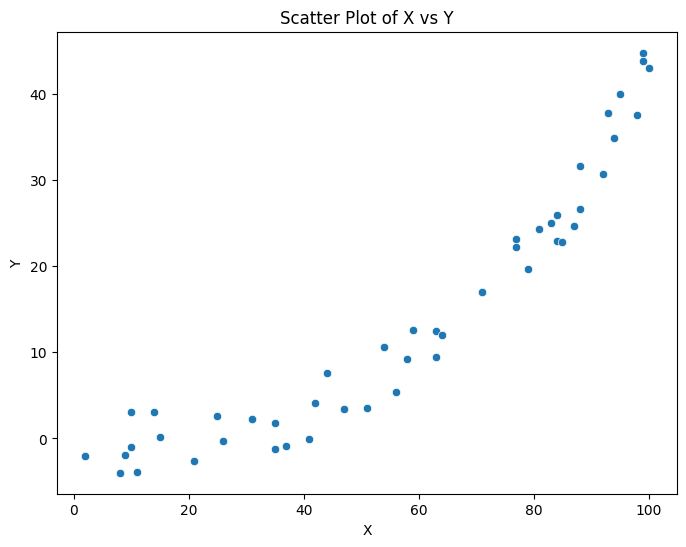

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=curve_df, x='x', y='y')
plt.title('Scatter Plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

It can be observed from above figure that the relation between y and x is not linear and looks like some polynomial. But we are not sure of the degree of the polynomial form. We need to try various polynomial forms of x and verify which model fits the data best.

To explore various polynomial forms, polyfit() from numpy library can be used. polyfit() takes X and Y values, and the degree of x features to be used to fit a model. Degree 1 means only value of x is used to predict y, whereas degree 2 means x and x^2 are used to predict y.

In [10]:
def fit_poly(degree):
    p = np.polyfit(curve_df.x, curve_df.y, deg = degree)
    curve_df['fit'] = np.polyval(p, curve_df.x)

    sns.regplot(x=curve_df.x, y=curve_df.y, fit_reg=False)
    return plt.plot(curve_df.x, curve_df.fit, label='fit')

Text(0, 0.5, 'Y values')

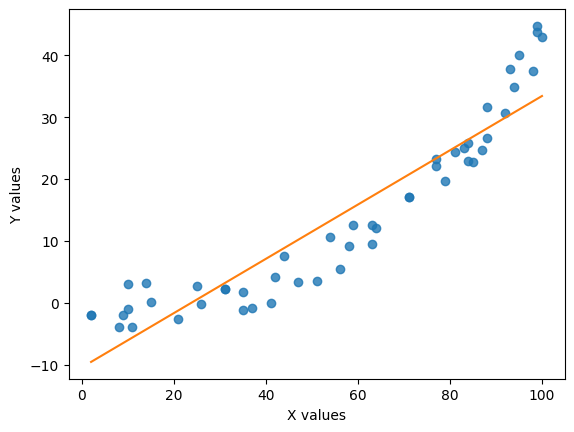

In [12]:
# Fitting a model with degree 1 (y = beta_1 * x_1 + epsilon)
fit_poly(1)
plt.xlabel('X values')
plt.ylabel('Y values')

Linear Model is shown in above figure. It is evident from the figure that the regression model does not seem to fit the data well. It is not able to learn from data as a simplistic form of model is assumed. This is a case of underfitting or bias.

Text(0, 0.5, 'Y values')

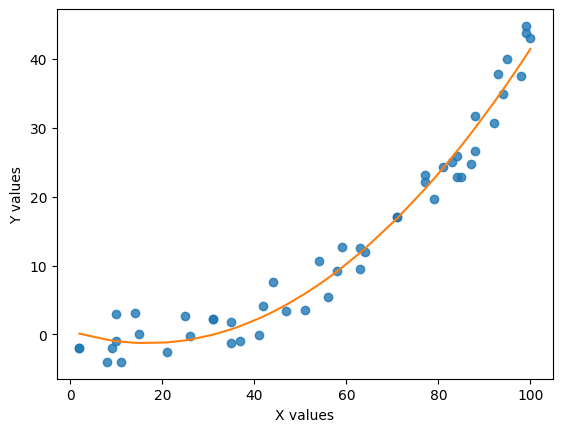

In [13]:
# Fitting a model with degree 2 (y = beta_1 * x_1 + beta_2 * x_1^2 + epsilon_i)
fit_poly(2)
plt.xlabel('X values')
plt.ylabel('Y values')

The above figure shows the fitted model which includes x_1 and x_1^2. The regression line seems to fit data better than the previous model. But we are not sure if this is the best model. We can try building a model with all polynomial terms up to degrees ranging from 1 to 10

Text(0, 0.5, 'Y values')

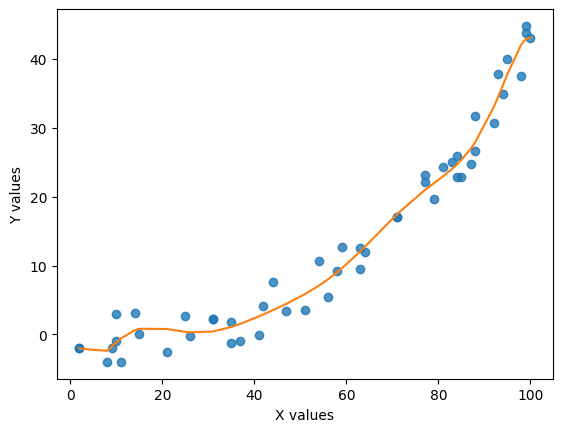

In [14]:
fit_poly(10)
plt.xlabel('X values')
plt.ylabel('Y values')

It can be observed from the above figure that as we build models with more and more polynomial terms, the model starts to fit every data point in the training set. This is the case of overfitting. The model with polynomial terms up to degree 10 will be sensitive to any changes in training examples. Any addition and removal of a single observation from the dataset can alter the model parameters significantly.

An underfitting model has a large error because of high bias, and an overfitting model has a large error because of high variance. An optimal model will be somewhere between an underfitting and an overfitting model, and will have low bias and low variance. This can be observed by comparing RMSE in training and test sets.

We use the following code to build models with degrees ranging from 1 to 15 and storing the degree and error details in different columns of a DataFrame named rmse_df.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
X_train, X_test, Y_train, Y_test = train_test_split(curve_df.x, curve_df.y, test_size=0.4, random_state=100)

rmse_df = pd.DataFrame(columns = ['Degree', 'RMSE_train', 'RMSE_test'])

def get_rmse(y, y_fit):
    return np.sqrt(metrics.mean_squared_error(y, y_fit))

# Iterate through polynomial degrees from 1 to 15
for degree in range(1, 16):
    p = np.polyfit(X_train, Y_train, deg=degree)
    rmse_df.loc[degree-1] = [degree,
                             get_rmse(Y_train, np.polyval(p, X_train)),
                             get_rmse(Y_test, np.polyval(p, X_test))]
    


rmse_df

,Degree,RMSE_train,RMSE_test
0,1.0,5.226638,5.779652
1,2.0,2.394509,2.755286
2,3.0,2.233547,2.560184
3,4.0,2.231998,2.549205
4,5.0,2.197528,2.428728
5,6.0,2.062201,2.703880
6,7.0,2.039408,2.909237
7,8.0,1.995852,3.270892
8,9.0,1.979322,3.120420
9,10.0,1.976326,3.115875


Text(0.5, 1.0, 'RMSE vs Polynomial Degree')

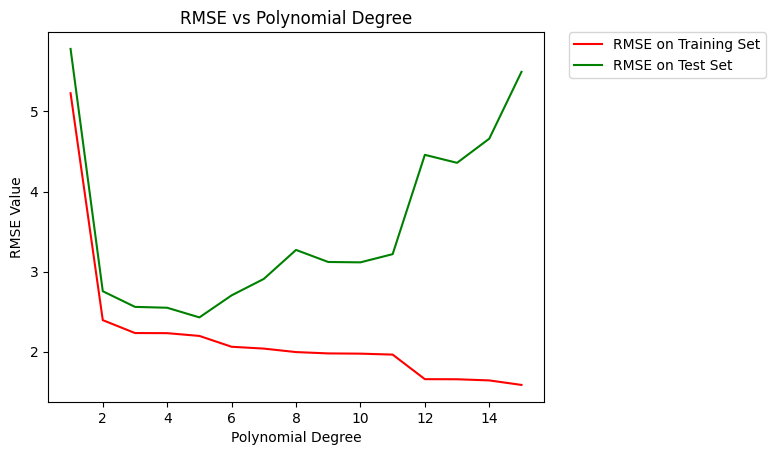

In [18]:
# Plotting the RMSE for training set in red color
plt.plot(rmse_df.Degree, rmse_df.RMSE_train, color='red', label='RMSE on Training Set')

# Plotting the RMSE for training set in red color
plt.plot(rmse_df.Degree, rmse_df.RMSE_test, color='g', label='RMSE on Test Set')

# Mentioning the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE Value')
plt.title('RMSE vs Polynomial Degree')

Three key observations for above figure are as follows:
1. Error on the test set are high for the model with complexity of degree 1 and degree 15.
2. Error on the test set reduces initially, however increases a$er a specific level of complexity.
3. Error on the training set decreases continuously.